## 1) Import Libraries

In [2]:
import pandas as pd
import numpy as np
import wbdata
import datetime
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## 2) Data Collection

Data is pulled directly from the World Bank Open Data API using the wbdata library. Two indicators are extracted: fertility rate and GDP per capita growth, across 30 European countries. The data is returned in a multi-index panel format with country and year as the two dimensions.

In [3]:
# Define the World Bank indicators to extract
indicators = {
    "SP.DYN.TFRT.IN": "fertility_rate",
    "NY.GDP.PCAP.KD.ZG": "gdp_per_capita_growth"
}

# 30 European countries using World Bank country codes
countries = [
    "DEU", "FRA", "ITA", "ESP", "POL", "SWE", "NLD", "BEL", "GRC", "PRT",
    "CZE", "HUN", "ROU", "AUT", "CHE", "NOR", "DNK", "FIN", "SVK", "BGR",
    "HRV", "SVN", "LTU", "LVA", "EST", "IRL", "GBR", "UKR", "SRB", "ALB"
]

# Pull data from the World Bank API
df = wbdata.get_dataframe(indicators, country=countries)

print(df.head(10))

              fertility_rate  gdp_per_capita_growth
country date                                       
Albania 2025             NaN                    NaN
        2024           1.341               5.663959
        2023           1.348               5.632935
        2022           1.355               6.456988
        2021           1.365              10.664149
        2020           1.371              -1.810165
        2019           1.395               3.649758
        2018           1.415               5.283579
        2017           1.486               4.889353
        2016           1.555               5.524826


## 3) Data Cleaning

The dataset is inspected for missing values before any analysis is carried out. Missing values are dropped and the data is trimmed to the 1990 to 2020 study period to remove incomplete observations outside the scope of the analysis.

In [4]:
# Check summary statistics to identify any data quality issues
df.describe()

,fertility_rate,gdp_per_capita_growth
count,1950.000000,1548.000000
mean,1.864498,2.341305
std,0.597398,4.314837
min,0.897000,-31.177519
25%,1.460000,0.793556
50%,1.730000,2.480599
75%,2.080000,4.507024
max,6.383000,42.016075


In [5]:
# Check missing value counts per variable
df.isnull().sum()

fertility_rate            30
gdp_per_capita_growth    432
dtype: int64

In [6]:
# Drop all rows with missing values
df = df.dropna()

# Reset index to bring country and date out as columns
df_reset = df.reset_index()

# Convert date column to datetime format
df_reset["date"] = pd.to_datetime(df_reset["date"])

# Trim to the 1990 to 2020 study period
df_model = df_reset[
    (df_reset["date"].dt.year >= 1990) &
    (df_reset["date"].dt.year <= 2020)
].copy()

# Add a numeric year column for use in the fixed effects model
df_model["year"] = df_model["date"].dt.year

print(f"Date range: {df_model['year'].min()} to {df_model['year'].max()}")
print(f"Observations: {df_model.shape[0]}")
print(f"Countries: {df_model['country'].nunique()}")

Date range: 1990 to 2020
Observations: 915
Countries: 30


## 4) Exploratory Data Analysis

A full visual exploration is carried out before modelling to understand the data structure, identify relationships and detect any outliers. The 2.1 replacement level is the fertility rate at which a population sustains itself without relying on migration, as defined by the United Nations and World Bank, and serves as the reference point throughout this analysis.

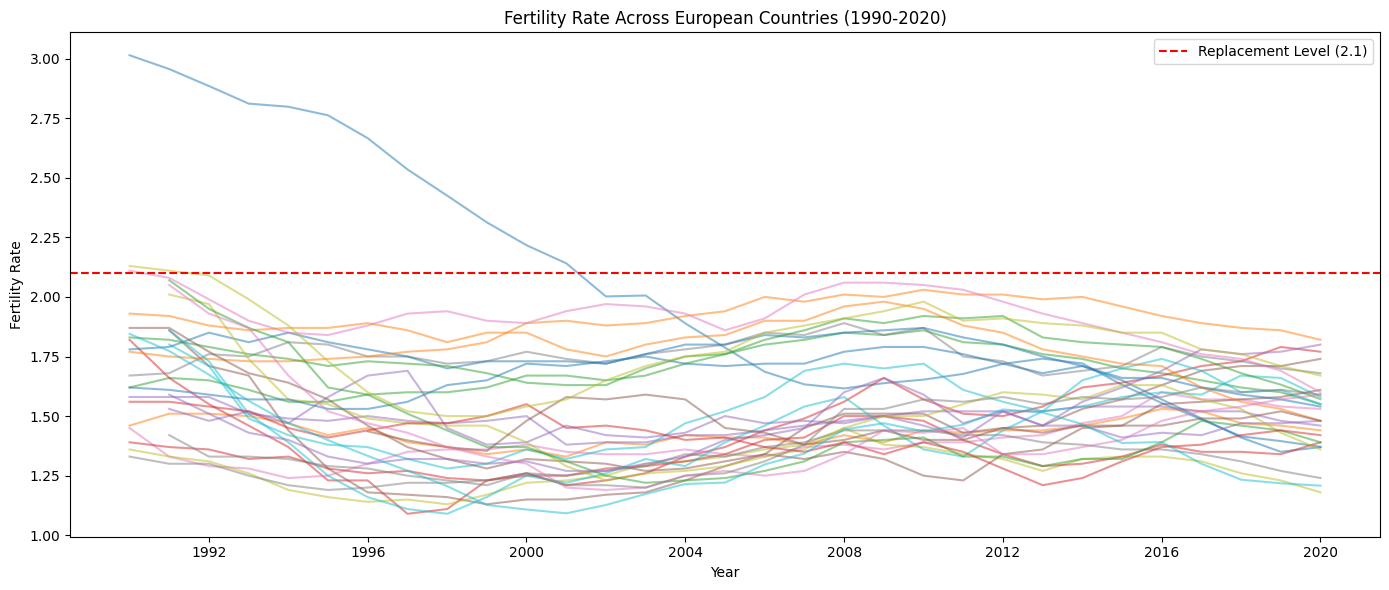

In [7]:
# Chart 1: Fertility rate trends across all 30 countries
# Shows the broad decline in birth rates relative to the 2.1 replacement threshold

plt.figure(figsize=(14, 6))
for country in df_model["country"].unique():
    country_data = df_model[df_model["country"] == country]
    plt.plot(country_data["date"], country_data["fertility_rate"], alpha=0.5)

plt.axhline(y=2.1, color="red", linestyle="--", linewidth=1.5, label="Replacement Level (2.1)")
plt.title("Fertility Rate Across European Countries (1990-2020)")
plt.xlabel("Year")
plt.ylabel("Fertility Rate")
plt.legend()
plt.tight_layout()
plt.show()

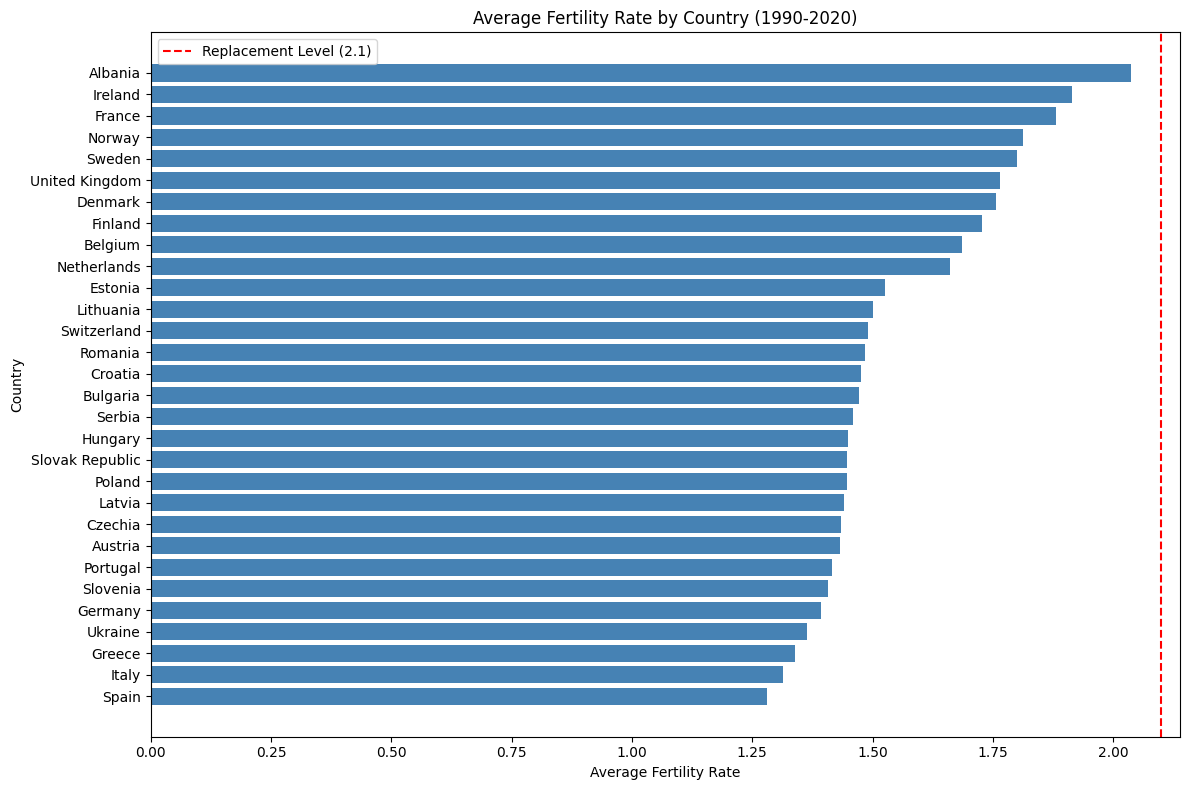

In [8]:
# Chart 2: Average fertility rate by country
# Ranks all 30 countries to show which are most affected by demographic decline

avg_fertility = df_model.groupby("country")["fertility_rate"].mean().sort_values()

plt.figure(figsize=(12, 8))
plt.barh(avg_fertility.index, avg_fertility.values, color="steelblue")
plt.axvline(x=2.1, color="red", linestyle="--", linewidth=1.5, label="Replacement Level (2.1)")
plt.title("Average Fertility Rate by Country (1990-2020)")
plt.xlabel("Average Fertility Rate")
plt.ylabel("Country")
plt.legend()
plt.tight_layout()
plt.show()

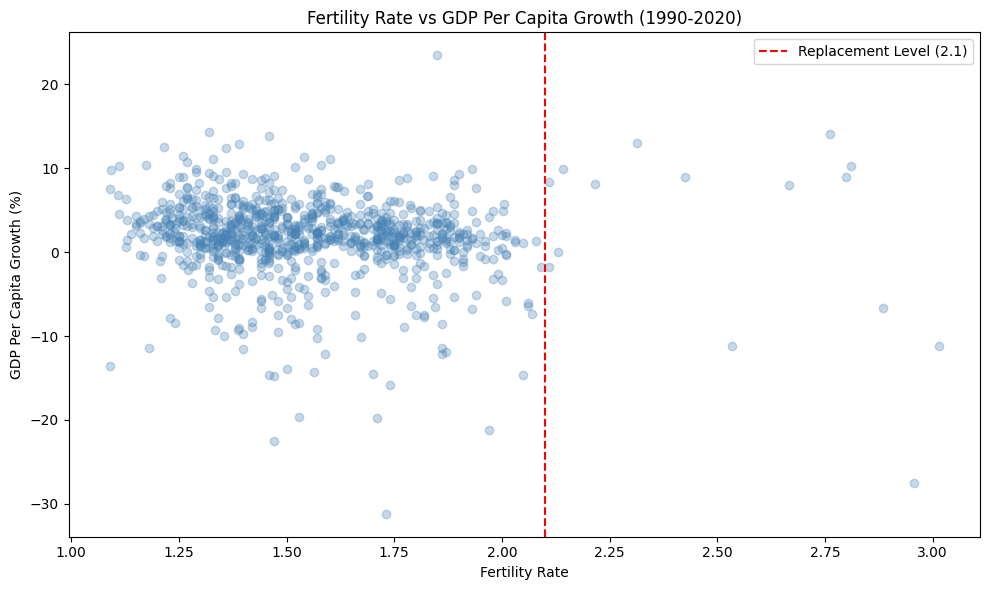

In [9]:
# Chart 3: Fertility rate vs GDP per capita growth scatter
# Explores the raw relationship between the two variables before modelling

plt.figure(figsize=(10, 6))
plt.scatter(df_model["fertility_rate"], df_model["gdp_per_capita_growth"], alpha=0.3, color="steelblue")
plt.axvline(x=2.1, color="red", linestyle="--", linewidth=1.5, label="Replacement Level (2.1)")
plt.title("Fertility Rate vs GDP Per Capita Growth (1990-2020)")
plt.xlabel("Fertility Rate")
plt.ylabel("GDP Per Capita Growth (%)")
plt.legend()
plt.tight_layout()
plt.show()

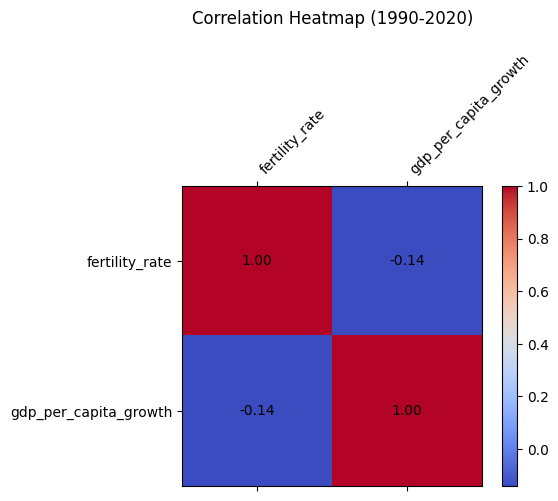

In [10]:
# Chart 4: Correlation heatmap
# Shows the pairwise correlation between fertility rate and GDP growth

corr_matrix = df_model[["fertility_rate", "gdp_per_capita_growth"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr_matrix, cmap="coolwarm")
fig.colorbar(cax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Heatmap (1990-2020)", pad=20)
plt.tight_layout()
plt.show()

## 5) Panel Data Modelling

A fixed effects OLS regression is specified using country and year dummies. This controls for unobserved country-specific characteristics that do not change over time, and for common time trends affecting all countries simultaneously. The approach isolates the within-country variation in fertility rate and its effect on GDP per capita growth, removing confounding factors that would otherwise bias the estimate.

In [11]:
# Fixed effects OLS regression
# Country and year dummies absorb unobserved heterogeneity across both dimensions

model_gdp = smf.ols(
    "gdp_per_capita_growth ~ fertility_rate + C(country) + C(year)",
    data=df_model
).fit()

print(model_gdp.summary())

                              OLS Regression Results                             
Dep. Variable:     gdp_per_capita_growth   R-squared:                       0.430
Model:                               OLS   Adj. R-squared:                  0.390
Method:                    Least Squares   F-statistic:                     10.76
Date:                   Sun, 28 Jun 2026   Prob (F-statistic):           6.31e-70
Time:                           20:55:30   Log-Likelihood:                -2465.3
No. Observations:                    915   AIC:                             5053.
Df Residuals:                        854   BIC:                             5347.
Df Model:                             60                                         
Covariance Type:               nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

## 6) Results Summary

The key result from the fixed effects model is extracted and presented clearly below.

In [12]:
# Extract the fertility rate coefficient and key model diagnostics
coef = round(model_gdp.params["fertility_rate"], 4)
pval = round(model_gdp.pvalues["fertility_rate"], 3)
rsq = round(model_gdp.rsquared, 3)
obs = int(model_gdp.nobs)

print("Fixed Effects Panel Regression Results")
print("Dependent Variable: GDP Per Capita Growth")
print("="*45)
print(f"Fertility Rate Coefficient : {coef}")
print(f"P-Value                    : {pval}")
print(f"R-Squared                  : {rsq}")
print(f"Observations               : {obs}")
print(f"Countries                  : 30")
print(f"Period                     : 1990 to 2020")
print("="*45)
print(f"Significant at 1% level    : {'Yes' if pval < 0.01 else 'No'}")

Fixed Effects Panel Regression Results
Dependent Variable: GDP Per Capita Growth
Fertility Rate Coefficient : -4.6563
P-Value                    : 0.0
R-Squared                  : 0.43
Observations               : 915
Countries                  : 30
Period                     : 1990 to 2020
Significant at 1% level    : Yes
